In [31]:
import pandas as pd
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TRAIN_DATA  = '../../data/processed/combined_hourly_regional_train.csv'
TEST_DATA   = '../../data/processed/combined_hourly_regional_test.csv'
SCALER_PATH = '../../data/processed/combined_hourly_regional_scaler.json'

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]

OTHER_FEATURES = ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                  'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES     = WEATHER_COLS + OTHER_FEATURES
LAG_FEATURES = FEATURES + [f'load_lag{i}' for i in range(1, 25)]

TARGET = 'load_mw'

torch.manual_seed(1)

### 1. Load pre-engineered data

In [32]:
train = pd.read_csv(TRAIN_DATA, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(TEST_DATA,  parse_dates=['datetime'], index_col='datetime')

with open(SCALER_PATH) as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

print(f'Train: {len(train):,}  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test):,}   {test.index[0].date()} to {test.index[-1].date()}')
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')
print(f'{len(LAG_FEATURES)} input features')

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
53 input features


### 2. Prepare tensors

In [33]:
def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

X_train = to_tensor(train, LAG_FEATURES)
y_train = to_tensor(train, [TARGET])
X_test  = to_tensor(test,  LAG_FEATURES)
y_test  = to_tensor(test,  [TARGET])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=2048, shuffle=True)
print('X_train shape:', X_train.shape)

X_train shape: torch.Size([42076, 53])


### 3. Define MLP

In [34]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden=(32, 16), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(in_features=len(LAG_FEATURES))
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=53, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parameters: 2,369


### 4. Train

In [35]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 100
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  train={train_loss:.4f}  test={test_loss:.4f}')

Epoch  10  train=0.0554  test=0.0295
Epoch  20  train=0.0418  test=0.0225
Epoch  30  train=0.0359  test=0.0195
Epoch  40  train=0.0329  test=0.0156
Epoch  50  train=0.0311  test=0.0145
Epoch  60  train=0.0279  test=0.0135
Epoch  70  train=0.0283  test=0.0123
Epoch  80  train=0.0281  test=0.0115
Epoch  90  train=0.0271  test=0.0113
Epoch 100  train=0.0275  test=0.0117


### 5. Loss curve

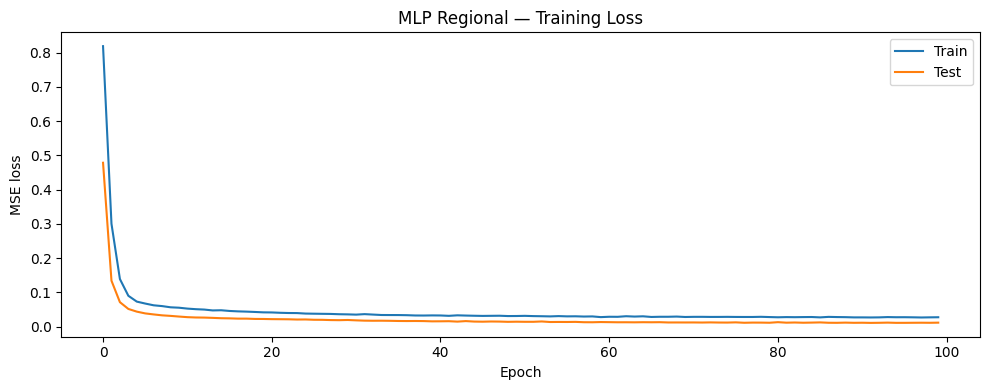

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(test_losses,  label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('MLP Regional — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 6. Evaluate on test set

In [37]:
model.eval()
with torch.no_grad():
    pred = model(X_test).squeeze().numpy()

y_true = y_test.squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'MLP Regional')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

MLP Regional
  RMSE  0.1083  (519 MW)
  MAE   0.0802  (384 MW)
  R2    0.9876


### 7. Predictions vs actuals (first 2 weeks of test)

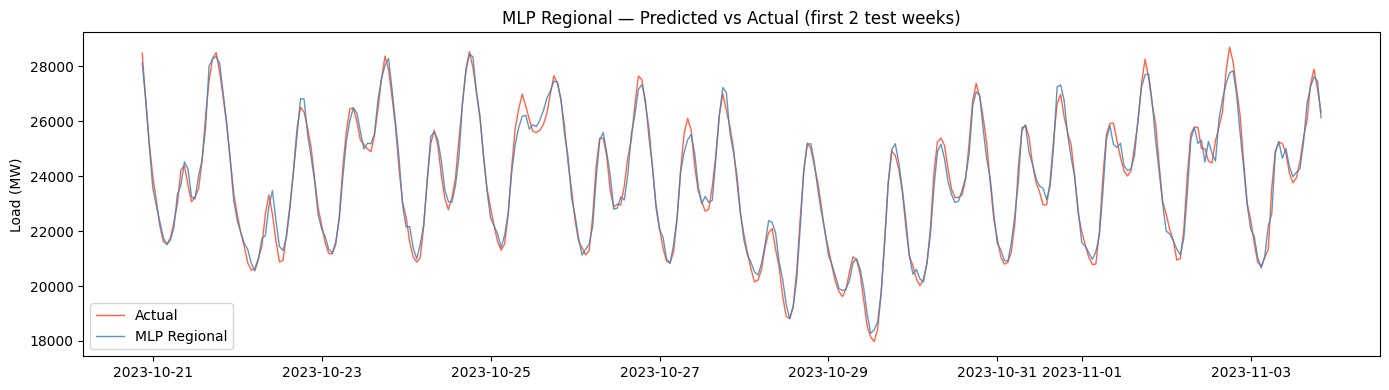

In [38]:
n   = 24 * 14
idx = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual,                          color='tomato',    linewidth=1,        label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='MLP Regional')
ax.set_ylabel('Load (MW)')
ax.set_title('MLP Regional — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()